# Business Context
Anna owns a clothing boutique called BrightThreads and aims to increase sales by 10% in the coming year. She is also considering opening a new store, so this analysis focuses on sales patterns, customer behavior, and product performance to support better business decisions. The analysis follows the OSEMN data analysis framework.

In [93]:
import pandas as pd

# Load all sheets
all_sheets = pd.read_excel("raw_data.xlsx", sheet_name=None)

for name, df in all_sheets.items():
    df["item_cost"] = pd.to_numeric(df["item_cost"], errors="coerce")
    all_sheets[name] = df

# See sheet names
all_sheets.keys()

dict_keys(['Dataset Segment 1', 'Dataset Segment 2', 'Dataset Segment 3', 'Dataset Segment 4'])

In [94]:
for name, df in all_sheets.items():
    print(f"\nSheet: {name}")
    print(df.head())
    print(df.info())


Sheet: Dataset Segment 1
   customer_id  order_number  customer_zip  item_sku item_category  item_cost
0     294381.0     2943811.0       21098.0  B7H9N3M5       Blouses      49.99
1     291085.0     2910851.0       45678.0  G7N2B6V9        Shorts      59.99
2     102537.0     1025371.0       23456.0  I3K8J7H9       Dresses     129.99
3     102537.0     1025371.0       23456.0  I3K8J7H9       Dresses     129.99
4     238194.0     2381941.0       89012.0  J4H9M2C7         Pants      79.99
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    10 non-null     float64
 1   order_number   10 non-null     float64
 2   customer_zip   10 non-null     float64
 3   item_sku       10 non-null     object 
 4   item_category  10 non-null     object 
 5   item_cost      10 non-null     float64
dtypes: float64(4), object(2)
memory usage: 608.0+ by

In [95]:
for name, df in all_sheets.items():
    df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce").astype("Int64").astype(str)
    df["order_number"] = pd.to_numeric(df["order_number"], errors="coerce").astype("Int64").astype(str)
    df["customer_zip"] = pd.to_numeric(df["customer_zip"], errors="coerce").astype("Int64").astype(str)

    all_sheets[name] = df  

I noticed that all sheets had the same issue where ID columns like customer_id, order_number, and customer_zip were stored as float. Since these are identifiers and not values for calculation, I converted them to string format.

In [96]:
df3 = all_sheets["Dataset Segment 3"]
df3.isnull().sum()

customer_id      0
order_number     0
customer_zip     0
item_sku         1
item_category    1
item_cost        1
dtype: int64

In [97]:
df3 = df3.dropna(how="all")   # removes fully empty rows

df3 = df3.dropna(subset=["item_sku", "item_cost"])  
# removes rows where key product info is missing

print("\nAfter cleaning:")
print(df3.shape)
print(df3.isnull().sum())



After cleaning:
(9, 6)
customer_id      0
order_number     0
customer_zip     0
item_sku         0
item_category    0
item_cost        0
dtype: int64


Segment 3 had several missing values across important columns. Some rows were missing key details like product and cost, making them unreliable for analysis.

I removed rows where critical information was missing, since keeping them would affect the accuracy of results.

In [98]:
df3["customer_zip"] = df3["customer_zip"].fillna("Unknown")

For the remaining data, a few missing values (like customer_zip) were kept and handled as "Unknown" to avoid unnecessary data loss.

In [99]:
for name, df in all_sheets.items():
    print(f"\n{name}")
    print(df["item_cost"].describe())


Dataset Segment 1
count     10.000000
mean     101.990000
std       44.422217
min       39.990000
25%       64.990000
50%      104.990000
75%      144.990000
max      149.990000
Name: item_cost, dtype: float64

Dataset Segment 2
count    10.000000
mean     61.992000
std      18.737722
min      39.990000
25%      49.990000
50%      59.995000
75%      69.997500
max      89.990000
Name: item_cost, dtype: float64

Dataset Segment 3
count      9.000000
mean      81.101111
std       28.037673
min       59.990000
25%       69.990000
50%       69.990000
75%       89.990000
max      149.990000
Name: item_cost, dtype: float64

Dataset Segment 4
count      10.000000
mean      652.898900
std      1878.590508
min         0.069000
25%        49.990000
50%        69.990000
75%        77.490000
max      5999.000000
Name: item_cost, dtype: float64


I analyzed the distribution of item_cost across all dataset segments. Most segments showed a consistent price range between approximately 40 and 150.

However, Segment 4 showed unusually high variation, with extreme values that significantly increased the mean and standard deviation. This indicated the presence of outliers that needed to be handled before further analysis.

In [100]:
df4["item_cost"].describe()

count     8.000000
mean     66.240000
std      15.059406
min      49.990000
25%      49.990000
50%      69.990000
75%      72.490000
max      89.990000
Name: item_cost, dtype: float64

In [101]:
cleaned_sheets = []

for name, df in all_sheets.items():
    df = df.dropna(how="all")
    df = df.dropna(subset=["item_sku", "item_cost"])
    df = df[(df["item_cost"] > 1) & (df["item_cost"] < 1000)]
    cleaned_sheets.append(df)

df = pd.concat(cleaned_sheets, ignore_index=True)

In [102]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    37 non-null     object 
 1   order_number   37 non-null     object 
 2   customer_zip   37 non-null     object 
 3   item_sku       37 non-null     object 
 4   item_category  37 non-null     object 
 5   item_cost      37 non-null     float64
dtypes: float64(1), object(5)
memory usage: 1.9+ KB


customer_id      0
order_number     0
customer_zip     0
item_sku         0
item_category    0
item_cost        0
dtype: int64

Top selling product category

In [103]:
df["item_category"].value_counts()

Sweaters     8
Jeans        6
Pants        4
Outerwear    4
Shirts       4
Shorts       3
Tops         3
Dresses      2
Skirts       2
Blouses      1
Name: item_category, dtype: int64

Revenue by category

In [104]:
df.groupby("item_category")["item_cost"].sum().sort_values(ascending=False)

item_category
Outerwear    599.96
Sweaters     559.93
Jeans        499.94
Pants        289.96
Dresses      259.98
Shirts       199.97
Shorts       179.97
Skirts       139.98
Tops         119.97
Blouses       49.99
Name: item_cost, dtype: float64

Avg price per category

In [105]:
df.groupby("item_category")["item_cost"].mean()

item_category
Blouses       49.990000
Dresses      129.990000
Jeans         83.323333
Outerwear    149.990000
Pants         72.490000
Shirts        49.992500
Shorts        59.990000
Skirts        69.990000
Sweaters      69.991250
Tops          39.990000
Name: item_cost, dtype: float64

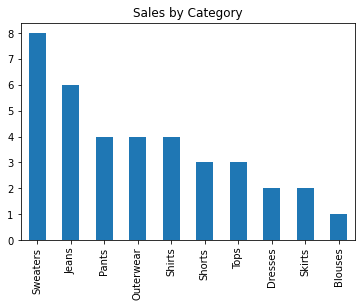

In [106]:
df["item_category"].value_counts().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

Sweaters have highest sales volume showing high demand

In [107]:
revenue_cat = df.groupby("item_category")["item_cost"].sum()
(revenue_cat / revenue_cat.sum()) * 100

item_category
Blouses       1.724001
Dresses       8.965910
Jeans        17.241391
Outerwear    20.690773
Pants         9.999828
Shirts        6.896350
Shorts        6.206611
Skirts        4.827479
Sweaters     19.310262
Tops          4.137396
Name: item_cost, dtype: float64

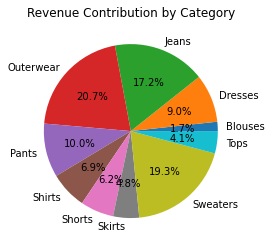

In [108]:
revenue_cat.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Contribution by Category")
plt.ylabel("")
plt.show()

Outerwear and sweaters generate the most revenue, showing strong demand. Jeans also perform consistently well. In contrast, blouses and tops contribute very little, suggesting low demand or the need for better marketing. Overall, revenue is concentrated in a few categories, which creates some dependency risk.

In [109]:
df.groupby("item_category")["item_cost"].agg(["mean", "count"])

,mean,count
item_category,,
Blouses,49.990000,1
Dresses,129.990000,2
Jeans,83.323333,6
Outerwear,149.990000,4
Pants,72.490000,4
Shirts,49.992500,4
Shorts,59.990000,3
Skirts,69.990000,2
Sweaters,69.991250,8


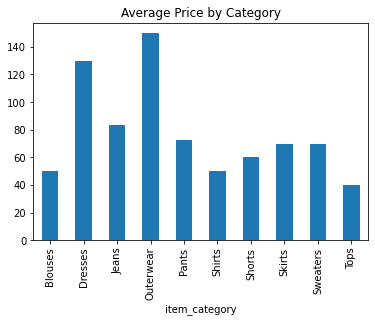

In [110]:
df.groupby("item_category")["item_cost"].mean().plot(kind="bar")
plt.title("Average Price by Category")
plt.show()

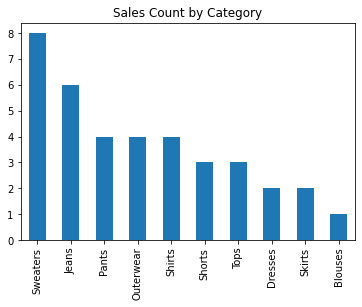

In [111]:
df["item_category"].value_counts().plot(kind="bar")
plt.title("Sales Count by Category")
plt.show()

Some categories make money by volume (Sweaters), others by high price (Outerwear/Dresses).

In [112]:
df["customer_id"].nunique()   # total customers
df["order_number"].nunique()  # total orders

28

In [113]:
df.groupby("customer_id")["order_number"].count().mean()

1.48

On average, each customer places about 1 to 2 orders, indicating low repeat purchase behavior.
This suggests that most customers are one-time buyers rather than returning customers.
There is a clear opportunity to improve customer retention and encourage repeat purchases.

In [114]:
df["customer_zip"].value_counts().head(5)

67890    9
45678    4
89012    4
56789    3
<NA>     3
Name: customer_zip, dtype: int64

Most customers come from zip code 67890, making it the primary customer location.
A few other zip codes contribute smaller numbers of customers, showing limited geographic spread.
Customer concentration in specific areas suggests a good opportunity to target marketing or open a new store in high-demand locations.

## Conclusion
Sales are mainly driven by categories like Outerwear and Sweaters. Customer repeat rate is low, and sales are concentrated in specific locations. These insights can help improve strategy to achieve a 10% increase in sales.

## Recommendation
- Focus on high-performing categories
- Improve customer retention
- Target top zip code areas

## OSEMN Framework

The following section summarizes the analysis using the OSEMN (Obtain, Scrub, Explore, Model, Interpret) framework.

### Obtain

- **Goal:** Increase total sales by 10% by understanding product performance and customer behavior.  
- **KPI:** Total Revenue (Sales).  
- **Data Needed:** Product details, order data, customer ID, and location (zip code).  
- **Source:** First-party data from sales records and online transactions.  

### Scrub

- Data contained missing values, inconsistent formats, and outliers.  
- Removed empty rows and handled missing key fields.  
- Standardized data types (IDs and zip codes).  
- Filtered unrealistic values in `item_cost` for accurate analysis.